In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, precision_recall_curve

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

In [2]:
# This is the core trick of the whole approach
X_train_legit = X_train[y_train == 0]
print(f"Training the autoencoder on {len(X_train_legit)} legitimate transactions only")
print(f"(Fraud examples are completely excluded from training — the model never sees them)")

scaler = StandardScaler()
X_train_legit_scaled = scaler.fit_transform(X_train_legit)
X_test_scaled = scaler.transform(X_test)

Training the autoencoder on 227451 legitimate transactions only
(Fraud examples are completely excluded from training — the model never sees them)


In [3]:
import sys
print(sys.executable)

C:\Users\Lenovo\AI\.venv\Scripts\python.exe


In [4]:
import torch
import torch.nn as nn

n_features = X_train_legit_scaled.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 20),
            nn.ReLU(),
            nn.Linear(20, 10),   # the bottleneck
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(10, 20),
            nn.ReLU(),
            nn.Linear(20, n_features)  # reconstruct back to original size
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder(n_features).to(device)
print(model)
print(f"Using device: {device}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=10, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=30, bias=True)
  )
)
Using device: cpu


In [5]:
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_legit_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # input = target
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 30
model.train()
for epoch in range(n_epochs):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

Epoch 5/30, Loss: 0.4872
Epoch 10/30, Loss: 0.4517
Epoch 15/30, Loss: 0.4175
Epoch 20/30, Loss: 0.4077
Epoch 25/30, Loss: 0.4052
Epoch 30/30, Loss: 0.4015


In [6]:
model.eval()
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    reconstructions = model(X_test_tensor).cpu().numpy()

mse = np.mean(np.square(X_test_scaled - reconstructions), axis=1)

print(f"Mean reconstruction error (legitimate): {mse[y_test == 0].mean():.4f}")
print(f"Mean reconstruction error (fraud):      {mse[y_test == 1].mean():.4f}")

Mean reconstruction error (legitimate): 0.4069
Mean reconstruction error (fraud):      22.0547


In [7]:
from sklearn.metrics import average_precision_score

auprc_ae = average_precision_score(y_test, mse)
print(f"Autoencoder AUPRC: {auprc_ae:.4f}")
print(f"(Compare to supervised XGBoost: 0.879)")

Autoencoder AUPRC: 0.3852
(Compare to supervised XGBoost: 0.879)


In [8]:
import pandas as pd

legit_errors = mse[y_test == 0]
fraud_errors = mse[y_test == 1]

print("Legitimate reconstruction error:")
print(pd.Series(legit_errors).describe())
print("\nFraud reconstruction error:")
print(pd.Series(fraud_errors).describe())

Legitimate reconstruction error:
count    56864.000000
mean         0.406875
std          1.249146
min          0.024386
25%          0.162045
50%          0.258837
75%          0.438910
max        102.591111
dtype: float64

Fraud reconstruction error:
count    98.000000
mean     22.054690
std      25.619384
min       0.153942
25%       4.263713
50%       9.807140
75%      28.788882
max      98.718300
dtype: float64


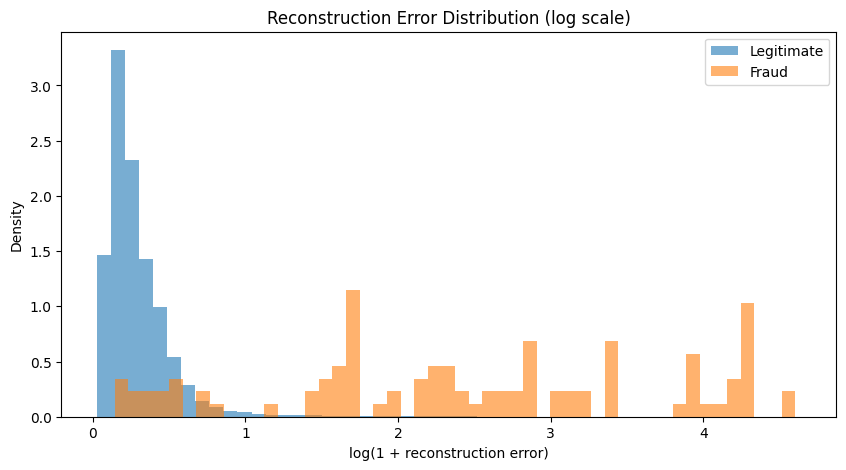

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(legit_errors), bins=50, alpha=0.6, label='Legitimate', density=True)
plt.hist(np.log1p(fraud_errors), bins=50, alpha=0.6, label='Fraud', density=True)
plt.xlabel('log(1 + reconstruction error)')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution (log scale)')
plt.legend()
plt.savefig("../outputs/06_autoencoder_error_dist.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
base_model = xgb.XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
base_model.fit(X_train, y_train)

calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)
proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print("Calibrated XGBoost reloaded.")

Calibrated XGBoost reloaded.


In [13]:
# Which fraud cases does the autoencoder score LOW (i.e. miss)?
fraud_mask = (y_test == 1).values
fraud_indices = np.where(fraud_mask)[0]
low_error_fraud = fraud_indices[mse[fraud_mask] < np.median(mse[fraud_mask])]

# Compare: does XGBoost (proba_calibrated) catch these specific ones?
print("Autoencoder-missed fraud cases — what does XGBoost say about them?")
print(pd.Series(proba_calibrated[low_error_fraud]).describe())

Autoencoder-missed fraud cases — what does XGBoost say about them?
count    49.000000
mean      0.625941
std       0.428581
min       0.000102
25%       0.037173
50%       0.901382
75%       0.987097
max       1.000000
dtype: float64
